# Regression Track: Dataset, EDA, and Preprocessing

This notebook performs exploratory data analysis (EDA), data cleaning, feature engineering, target log-transformation, and preprocessing for the SPARCS Hospital Inpatient Discharges regression dataset.


In [1]:
import os
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")


In [2]:
# Load dataset (handles execution from notebooks/ or project root)
csv_path = "../regression_dataset/hospital-inpatient-discharges-sparcs-de-identified-2010-1.csv"
if not os.path.exists(csv_path):
    csv_path = "regression_dataset/hospital-inpatient-discharges-sparcs-de-identified-2010-1.csv"

df = pd.read_csv(csv_path, low_memory=False)

target_column = "Length of Stay"
print(f"Loaded dataset path : {csv_path}")
print(f"Initial Dataset Shape: {df.shape}")


Loaded dataset path : ../regression_dataset/hospital-inpatient-discharges-sparcs-de-identified-2010-1.csv
Initial Dataset Shape: (50000, 38)


In [3]:
# 1. Target & Data Cleaning
# Clean Length of Stay (strip '+' before coercing so '120 +' stays are preserved)
df[target_column] = pd.to_numeric(df[target_column].astype(str).str.replace("+", "", regex=False).str.strip(), errors="coerce")

# Remove duplicate rows
duplicate_count = df.duplicated().sum()
df = df.drop_duplicates().copy()

# Remove invalid target rows
df = df[df[target_column].notna() & (df[target_column] >= 0)].copy()

print(f"Duplicate rows removed: {duplicate_count}")
print(f"Cleaned dataset shape: {df.shape}")


Duplicate rows removed: 0
Cleaned dataset shape: (50000, 38)


In [4]:
# 2. Feature Selection & Feature Engineering
columns_to_remove = [
    "index",
    "Length of Stay",
    "Total Charges",
    "Total Costs",
    "Operating Certificate Number",
    "Facility ID",
    "Attending Provider License Number",
    "Operating Provider License Number",
    "Other Provider License Number",
    "Discharge Year",  # Constant 2010
    "CCS Diagnosis Description",  # Redundant with CCS Diagnosis Code
    "CCS Procedure Description",  # Redundant with CCS Procedure Code
    "APR DRG Description",        # Redundant with APR DRG Code
    "APR MDC Description",        # Redundant with APR MDC Code
    "APR Severity of Illness Description"  # Redundant with APR Severity Code
]

feature_columns = [col for col in df.columns if col not in columns_to_remove]
X = df[feature_columns].copy()
y = df[target_column].copy()

# Engineered Features
age_group_midpoints = {
    "0 to 17": 8.5,
    "18 to 29": 23.5,
    "30 to 49": 39.5,
    "50 to 69": 59.5,
    "70 or Older": 80.0
}
X["Age Group Midpoint"] = X["Age Group"].map(age_group_midpoints)

rom_map = {"Minor": 1, "Moderate": 2, "Major": 3, "Extreme": 4}
X["APR Risk of Mortality Num"] = X["APR Risk of Mortality"].map(rom_map).fillna(0)

ed_map = {"Y": 1, "N": 0}
X["Emergency Dept Num"] = X["Emergency Department Indicator"].map(ed_map).fillna(0)

X["Birth Weight Num"] = pd.to_numeric(X["Birth Weight"], errors="coerce").fillna(0)
X["Is Newborn"] = (X["Birth Weight Num"] > 0).astype(int)

X["APR Severity of Illness Code"] = pd.to_numeric(X["APR Severity of Illness Code"], errors="coerce").fillna(0)

# Convert high-cardinality codes to string types
code_cols = ["CCS Diagnosis Code", "CCS Procedure Code", "APR DRG Code", "APR MDC Code", "Facility Name", "Zip Code - 3 digits"]
for col in code_cols:
    if col in X.columns:
        X[col] = X[col].astype(str)

print(f"Feature matrix shape: {X.shape}")


Feature matrix shape: (50000, 28)


In [5]:
# Separate numeric and categorical features
numeric_columns = [
    "Age Group Midpoint",
    "APR Risk of Mortality Num",
    "Emergency Dept Num",
    "Birth Weight Num",
    "Is Newborn",
    "APR Severity of Illness Code"
]

categorical_columns = [col for col in X.columns if col not in numeric_columns]

for col in categorical_columns:
    X[col] = X[col].fillna("Missing").astype(str)

print(f"Numeric feature count    : {len(numeric_columns)}")
print(f"Categorical feature count: {len(categorical_columns)}")


Numeric feature count    : 6
Categorical feature count: 22


In [6]:
# 3. Target Log Transformation & Distribution Summary
y_log = np.log1p(y)

print("Target Summary (Raw Length of Stay):")
print(y.describe())

print("Target Summary (Log1p Length of Stay):")
print(y_log.describe())


Target Summary (Raw Length of Stay):
count    50000.000000
mean        12.632120
std         18.414825
min          1.000000
25%          2.750000
50%          5.500000
75%         14.250000
max        120.000000
Name: Length of Stay, dtype: float64
Target Summary (Log1p Length of Stay):
count    50000.000000
mean         2.040212
std          1.007511
min          0.693147
25%          1.314374
50%          1.868835
75%          2.724185
max          4.795791
Name: Length of Stay, dtype: float64


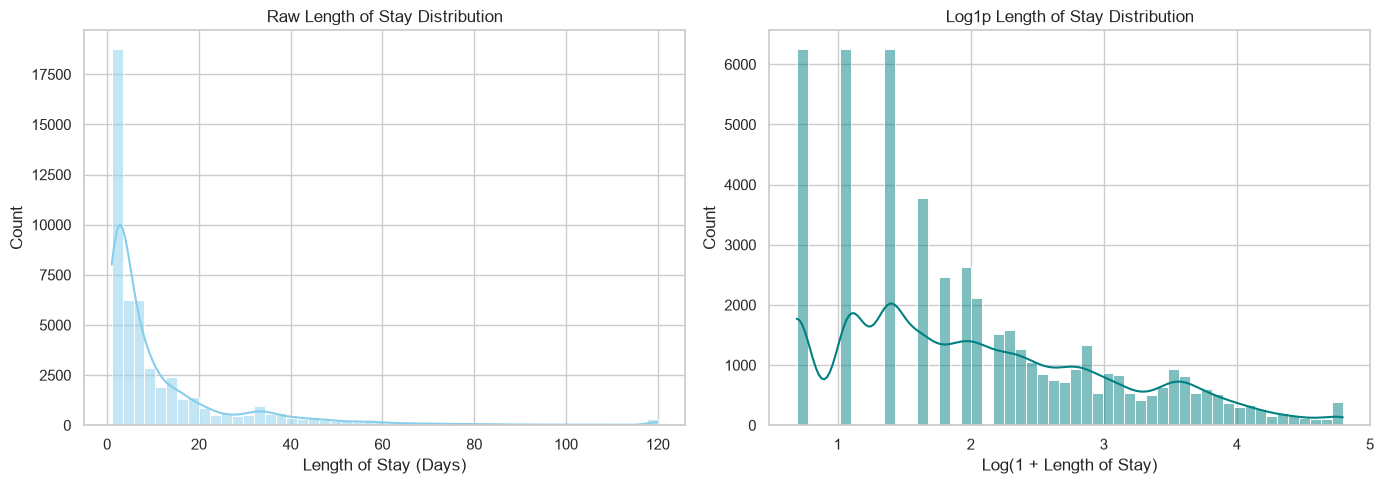

In [7]:
# 4. EDA Visualizations - Target Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(y, bins=50, kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Raw Length of Stay Distribution")
axes[0].set_xlabel("Length of Stay (Days)")

sns.histplot(y_log, bins=50, kde=True, ax=axes[1], color="teal")
axes[1].set_title("Log1p Length of Stay Distribution")
axes[1].set_xlabel("Log(1 + Length of Stay)")

plt.tight_layout()
plt.show()


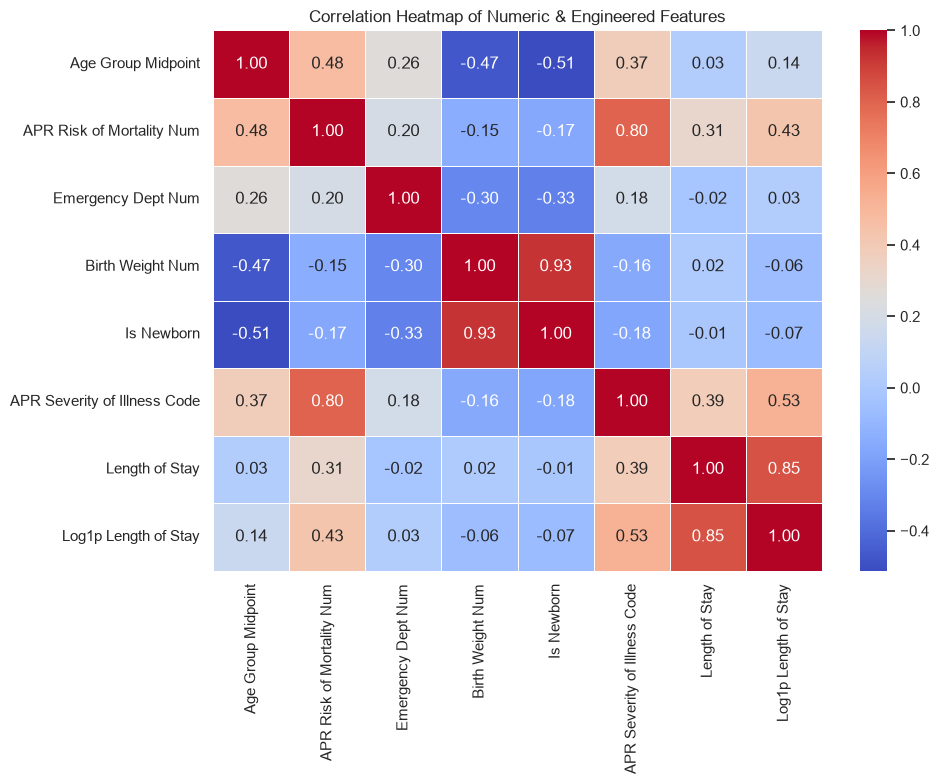

In [8]:
# 5. Correlation Heatmap for Numeric Features
numeric_df = X[numeric_columns].copy()
numeric_df["Length of Stay"] = y
numeric_df["Log1p Length of Stay"] = y_log

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric & Engineered Features")
plt.tight_layout()
plt.show()


In [9]:
# 6. Train-Test Split (70/30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f"Training set shape: {X_train.shape}, Target shape: {y_train.shape}")
print(f"Testing set shape : {X_test.shape}, Target shape: {y_test.shape}")


Training set shape: (35000, 28), Target shape: (35000,)
Testing set shape : (15000, 28), Target shape: (15000,)


In [10]:
# 7. Preprocessing Pipelines (Sparse Output for Efficiency)
numeric_steps = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_steps = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore", min_frequency=10, sparse_output=True))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_steps, numeric_columns),
    ("categorical", categorical_steps, categorical_columns)
])

X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

all_feature_cols = preprocessor.get_feature_names_out()

print(f"Encoded Training Features Shape: {X_train_encoded.shape}")
print(f"Encoded Testing Features Shape : {X_test_encoded.shape}")
print(f"Total Processed Features       : {len(all_feature_cols)}")


Encoded Training Features Shape: (35000, 1160)
Encoded Testing Features Shape : (15000, 1160)
Total Processed Features       : 1160
